## Short form Video classifer

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import numpy as np
import matplotlib.pyplot as plt

import re
from pathlib import Path

In [2]:
df = pd.read_json('../data/video/videodata.json')
df['label'] = df['label'].map({'false': 1, 'true': 0})
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2393, 7)


,video_id,class,contextual_class,label,subject,title,audio_transcript
0,__HPCmizGfc,fv,,1,2024 US presidential election,Sky polling puts Kamala Harris ahead | US Elec...,Kamala Harris is gaining support as the electi...
1,_0oux8o9MJo,,,0,2024 US presidential election,Donald Trump wins 2024 presidential election,It's been a long night and we'll start right n...
2,_1wB0eT6YSo,,,0,2024 US presidential election,stYpe Technology | Croatia Presidential Electi...,
3,_6kQkSBP84U,,,0,disaster,100-Year-Old Woman Speaks Out After LA Fire Re...,The other day we told you about the 100 year o...
4,_9Bdsey4XFQ,fv,,1,2024 Paris Olympics,Mixed 4×400 metres relay Final | Paris Champions,The final of the mixed 4×400 meters relay at t...


In [3]:
df = df.drop(columns=['class', 'contextual_class', 'video_id', 'subject'])
df['transcript_length'] = df['audio_transcript'].apply(len)
#df.head()

In [4]:
df['transcript_length'].describe()

count    2393.000000
mean      480.330547
std       550.744355
min         0.000000
25%         0.000000
50%       331.000000
75%       820.000000
max      2921.000000
Name: transcript_length, dtype: float64

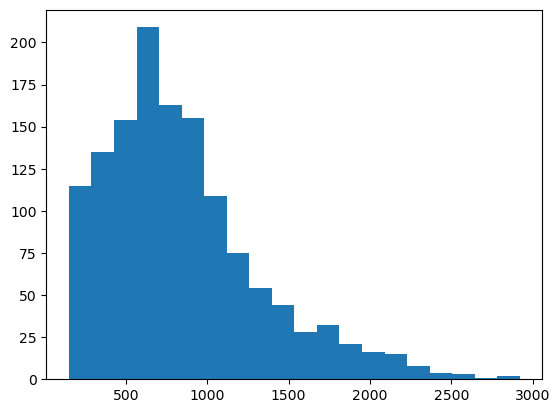

In [5]:
# Mean title length is 144
plt.hist(df['transcript_length'][df['transcript_length'] >= 150], bins=20)
plt.show()

In [6]:
df['label'][df['transcript_length'] >= 150].value_counts()

label
1    814
0    529
Name: count, dtype: int64

### W/ Title

In [7]:
# Median Title length is 124
df_title = df
df_title['audio_transcript'] = df['title'] + ' -- ' + df['audio_transcript']
df_title['transcript_length'] = df_title['audio_transcript'].apply(len)
df_balanced = df_title[df_title['transcript_length'] >= 150 + 124]


In [8]:
def clean_text(text):
    # 1. Remove Publisher tags (ISOT specific)
    #text = re.sub(r'^.*? - ', '', text)

    # Remove URLs
    #text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove email addresses
    #text = re.sub(r'\S+@\S+', '', text)
    
    # 3. Standard cleaning
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s!\?-]', '', text) # Keep text, spaces, !, and ?
    return text

df_title['audio_transcript'] = df_title['audio_transcript'].apply(clean_text)

In [9]:
df_title['audio_transcript'].iloc[0]

'sky polling puts kamala harris ahead  us election 2024 -- kamala harris is gaining support as the election nears especially among women in pennsylvania polls show surprising backing for her among independent and older women a republican voter expresses support for harris citing her values of truth and justice they believe democracy is at risk which could impact womens rights women are seen as crucial for the election but men should also recognize the government shouldnt interfere with personal decisions like abortion harris avoids mentioning donald trump highlighting her differences from other candidates while urging voter turnout in her final push she brings celebrity appeal to pennsylvania appearing with lady gaga and oprah winfrey rumors of taylor swift joining persist some apathetic voters are still persuadable with one saying they trust harris more than politicians harriss team believes the key is to mobilize all voters they assert she is no longer the underdog martha keller sky 

In [11]:
X, y = df_title['audio_transcript'], df_title['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [32]:
pipeline = make_pipeline(
    TfidfVectorizer(stop_words='english', max_df=0.7, ngram_range=(1, 2), max_features=5000),
    SGDClassifier(loss='hinge', penalty=None, eta0=1.0, random_state=42)
)

weights = np.linspace(1, 10, 10)
param_grid = {
    'sgdclassifier__class_weight' : [{0: 1, 1: w} for w in weights] + ['balanced'],
    'sgdclassifier__alpha': [1e-4, 1e-3, 1e-2],
    'sgdclassifier__learning_rate': ['pa1', 'pa2']
}

search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2
)

In [33]:
search.fit(X_train, y_train)
search.best_params_

Fitting 5 folds for each of 66 candidates, totalling 330 fits
[CV] END sgdclassifier__alpha=0.0001, sgdclassifier__class_weight={0: 1, 1: np.float64(1.0)}, sgdclassifier__learning_rate=pa1; total time=   0.4s
[CV] END sgdclassifier__alpha=0.0001, sgdclassifier__class_weight={0: 1, 1: np.float64(1.0)}, sgdclassifier__learning_rate=pa1; total time=   0.4s
[CV] END sgdclassifier__alpha=0.0001, sgdclassifier__class_weight={0: 1, 1: np.float64(1.0)}, sgdclassifier__learning_rate=pa1; total time=   0.4s
[CV] END sgdclassifier__alpha=0.0001, sgdclassifier__class_weight={0: 1, 1: np.float64(1.0)}, sgdclassifier__learning_rate=pa1; total time=   0.4s
[CV] END sgdclassifier__alpha=0.0001, sgdclassifier__class_weight={0: 1, 1: np.float64(1.0)}, sgdclassifier__learning_rate=pa1; total time=   0.4s
[CV] END sgdclassifier__alpha=0.0001, sgdclassifier__class_weight={0: 1, 1: np.float64(1.0)}, sgdclassifier__learning_rate=pa2; total time=   0.4s
[CV] END sgdclassifier__alpha=0.0001, sgdclassifier__cla

{'sgdclassifier__alpha': 0.0001,
 'sgdclassifier__class_weight': {0: 1, 1: np.float64(5.0)},
 'sgdclassifier__learning_rate': 'pa1'}

In [28]:
results = pd.DataFrame(search.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_sgdclassifier__alpha,param_sgdclassifier__class_weight,param_sgdclassifier__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.463107,0.103377,0.063375,0.025478,0.0001,"{0: 1, 1: 1.0}",pa1,"{'sgdclassifier__alpha': 0.0001, 'sgdclassifie...",0.678851,0.691906,0.704961,0.733681,0.706806,0.703241,0.018252,10
1,0.361422,0.028996,0.040712,0.002359,0.0001,"{0: 1, 1: 1.0}",pa2,"{'sgdclassifier__alpha': 0.0001, 'sgdclassifie...",0.689295,0.704961,0.678851,0.725849,0.709424,0.701676,0.016306,19
2,0.341341,0.022215,0.038398,0.001252,0.0001,"{0: 1, 1: 2.0}",pa1,"{'sgdclassifier__alpha': 0.0001, 'sgdclassifie...",0.686684,0.681462,0.702350,0.733681,0.712042,0.703244,0.018726,7
3,0.336965,0.006344,0.039256,0.001193,0.0001,"{0: 1, 1: 2.0}",pa2,"{'sgdclassifier__alpha': 0.0001, 'sgdclassifie...",0.689295,0.691906,0.684073,0.725849,0.712042,0.700633,0.015779,25
4,0.331530,0.002498,0.039591,0.001652,0.0001,"{0: 1, 1: 3.0}",pa1,"{'sgdclassifier__alpha': 0.0001, 'sgdclassifie...",0.699739,0.704961,0.694517,0.725849,0.714660,0.707945,0.011155,4


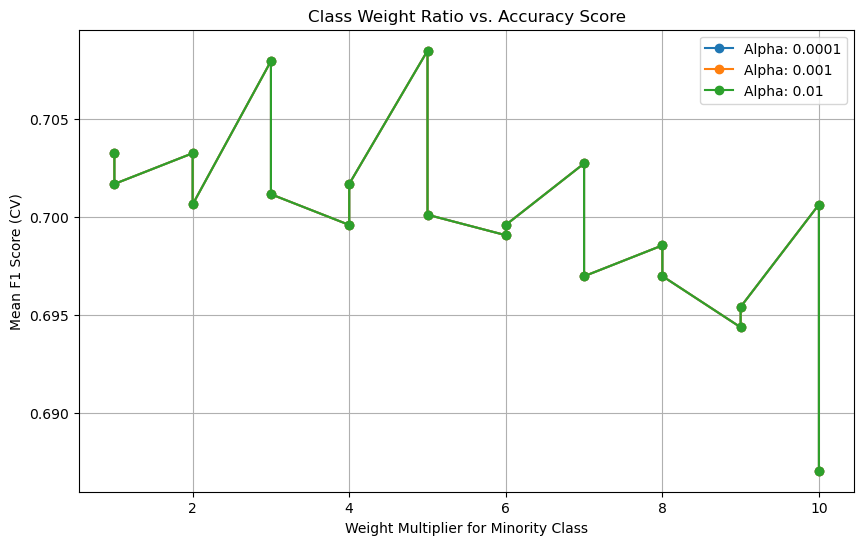

In [29]:
# 3. Extract results into a DataFrame
results = pd.DataFrame(search.cv_results_)

# We need to extract the 'w' value from the dictionary for plotting
results['minority_weight'] = results['param_sgdclassifier__class_weight'].apply(lambda x: x[1])

# 4. Plotting
# Note: If you have other params (like alpha), you might want to group by them 
# or just plot the best performing line.
plt.figure(figsize=(10, 6))
for alpha in param_grid['sgdclassifier__alpha']:
    subset = results[results['param_sgdclassifier__alpha'] == alpha]
    plt.plot(subset['minority_weight'], subset['mean_test_score'], marker='o', label=f'Alpha: {alpha}')

plt.title('Class Weight Ratio vs. Accuracy Score')
plt.xlabel('Weight Multiplier for Minority Class')
plt.ylabel('Mean F1 Score (CV)')
plt.legend()
plt.grid(True)
plt.show()

{'sgdclassifier__alpha': 0.0001, 'sgdclassifier__learning_rate': 'pa2'}

In [30]:
y_pred = search.predict(X_test)

In [31]:
print("Test Accuracy:", accuracy_score(y_true=y_test, y_pred=y_pred))
print(classification_report(y_true=y_test, y_pred=y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.6680584551148225
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       174
           1       0.73      0.75      0.74       305

    accuracy                           0.67       479
   macro avg       0.64      0.64      0.64       479
weighted avg       0.67      0.67      0.67       479

Confusion Matrix:
 [[ 91  83]
 [ 76 229]]


## No Class Balancing - w/o Title

In [257]:
df_mod = df[df['transcript_length'] >= 150]
df_mod['audio_transcript'] = df_mod['audio_transcript'].apply(clean_text)
X, y = df_mod['audio_transcript'], df_mod['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
search.fit(X_train, y_train)
search.best_params_

/var/folders/_v/ncwq304d761gb02f1n7x_2vr0000gn/T/ipykernel_27656/657085981.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mod['audio_transcript'] = df_mod['audio_transcript'].apply(clean_text)


{'sgdclassifier__alpha': 0.0001, 'sgdclassifier__learning_rate': 'pa1'}

In [258]:
y_pred = search.predict(X_test)
print("Test Accuracy:", accuracy_score(y_true=y_test, y_pred=y_pred))
print(classification_report(y_true=y_test, y_pred=y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.7522123893805309
              precision    recall  f1-score   support

           0       0.64      0.65      0.64       156
           1       0.81      0.81      0.81       296

    accuracy                           0.75       452
   macro avg       0.73      0.73      0.73       452
weighted avg       0.75      0.75      0.75       452

Confusion Matrix:
 [[101  55]
 [ 57 239]]


## Class Balancing w/ No Title

In [260]:
df_mod = df[df['transcript_length'] >= 150]
df_false = df_mod[df_mod['label'] == 1]
df_true = df_mod[df_mod['label'] == 0]
df_mod['label'].value_counts()

label
1    1422
0     835
Name: count, dtype: int64

In [ ]:
df_false = df_false.sample(n=835, random_state=42)
df_mod = pd.concat([df_false, df_true])

In [262]:
df_mod['audio_transcript'] = df_mod['audio_transcript'].apply(clean_text)

In [263]:
X, y = df_mod['audio_transcript'], df_mod['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
search.fit(X_train, y_train)
search.best_params_

{'sgdclassifier__alpha': 0.0001, 'sgdclassifier__learning_rate': 'pa1'}

In [264]:
y_pred = search.predict(X_test)
print("Test Accuracy:", accuracy_score(y_true=y_test, y_pred=y_pred))
print(classification_report(y_true=y_test, y_pred=y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.6826347305389222
              precision    recall  f1-score   support

           0       0.64      0.74      0.68       155
           1       0.74      0.64      0.68       179

    accuracy                           0.68       334
   macro avg       0.69      0.69      0.68       334
weighted avg       0.69      0.68      0.68       334

Confusion Matrix:
 [[114  41]
 [ 65 114]]


## No Class Balancing w/ Title

In [265]:
df_mod = df
df_mod['audio_transcript'] = df_mod['title'] + ' -- ' + df_mod['audio_transcript']
df_mod['transcript_length'] = df_mod['audio_transcript'].apply(len)
df_mod = df_mod[df['transcript_length'] > 150 + 124]
df_mod['audio_transcript'] = df_mod['audio_transcript'].apply(clean_text)

/var/folders/_v/ncwq304d761gb02f1n7x_2vr0000gn/T/ipykernel_27656/751789460.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mod['audio_transcript'] = df_mod['audio_transcript'].apply(clean_text)


In [266]:
X, y = df_mod['audio_transcript'], df_mod['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
search.fit(X_train, y_train)
search.best_params_

{'sgdclassifier__alpha': 0.0001, 'sgdclassifier__learning_rate': 'pa1'}

In [267]:
y_pred = search.predict(X_test)
print("Test Accuracy:", accuracy_score(y_true=y_test, y_pred=y_pred))
print(classification_report(y_true=y_test, y_pred=y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.7106481481481481
              precision    recall  f1-score   support

           0       0.61      0.58      0.60       159
           1       0.76      0.78      0.77       273

    accuracy                           0.71       432
   macro avg       0.69      0.68      0.69       432
weighted avg       0.71      0.71      0.71       432

Confusion Matrix:
 [[ 93  66]
 [ 59 214]]
